In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eralpozcan/resistor-dataset")

print("Path to dataset files:", path)

# ============================================================
# Transfer Learning (VGG16) vs Bespoke CNN
# Resistor Classification – 37 Classes
# Platform: Google Colab + TensorFlow / Keras
# ============================================================

!pip -q install kagglehub

import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. DATA IMPORT (EXACTLY AS SPECIFIED)
# ------------------------------------------------------------
path = kagglehub.dataset_download("eralpozcan/resistor-dataset")
print("Path to dataset files:", path)

def mean_subtract(x, y):
    return x - train_mean, y

Using Colab cache for faster access to the 'resistor-dataset' dataset.
Path to dataset files: /kaggle/input/resistor-dataset
Using Colab cache for faster access to the 'resistor-dataset' dataset.
Path to dataset files: /kaggle/input/resistor-dataset


In [2]:
import matplotlib.pyplot as plt

def plot_history(history, title):

    plt.figure(figsize=(10,4))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [3]:
# 2. DATASET SETUP (60 : 20 : 20 split)
# ------------------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load full dataset (folder-per-class structure)
full_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = full_ds.class_names
NUM_CLASSES = len(class_names)
print("Number of classes:", NUM_CLASSES)

# Shuffle dataset
full_ds = full_ds.shuffle(1000, seed=SEED)

# Compute split sizes
dataset_size = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.6 * dataset_size)
val_size   = int(0.2 * dataset_size)

train_ds = full_ds.take(train_size)
val_ds   = full_ds.skip(train_size).take(val_size)
test_ds  = full_ds.skip(train_size + val_size)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 2881 files belonging to 37 classes.
Number of classes: 37


In [4]:
# 3. PART A — VGG16 TRANSFER LEARNING
# ------------------------------------------------------------
from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models

# VGG16 preprocessing
train_vgg = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_vgg   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_vgg  = test_ds.map(lambda x, y: (preprocess_input(x), y))

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze original VGG16

vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nVGG16 MODEL SUMMARY")
vgg_model.summary()

history_vgg = vgg_model.fit(
    train_vgg,
    validation_data=val_vgg,
    epochs=10
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

VGG16 MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,669 (56.20 MB)

 Trainable params: 18,981 (74.14 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 490ms/step - accuracy: 0.0843 - loss: 4.0748 - val_accuracy: 0.1788 - val_loss: 2.9931
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 556ms/step - accuracy: 0.2801 - loss: 2.5706 - val_accuracy: 0.3945 - val_loss: 2.1685
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 454ms/step - accuracy: 0.4266 - loss: 2.0055 - val_accuracy: 0.5312 - val_loss: 1.6468
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 466ms/step - accuracy: 0.5509 - loss: 1.5722 - val_accuracy: 0.6128 - val_loss: 1.3902
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 569ms/step - accuracy: 0.6319 - loss: 1.3405 - val_accuracy: 0.6550 - val_loss: 1.2214
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 574ms/step - accuracy: 0.6889 - loss: 1.1420 - val_accuracy: 0.7292 - val_loss: 1.0777
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 496ms/step - accuracy: 0.7396 - loss: 1.0233 - val_accuracy: 0.7622 - val_loss: 0.9860
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 604ms/step - accuracy: 0.7807 - loss: 0.8926 - val_accu

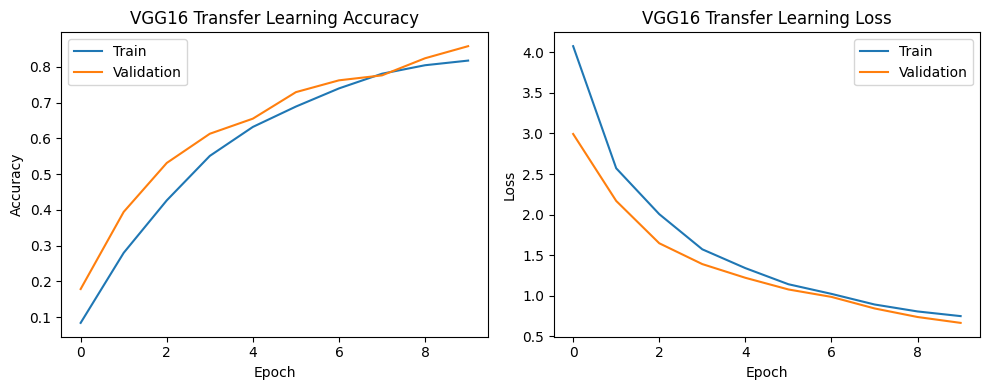

19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.8423 - loss: 0.7055
VGG16 Test Accuracy: 0.8423
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


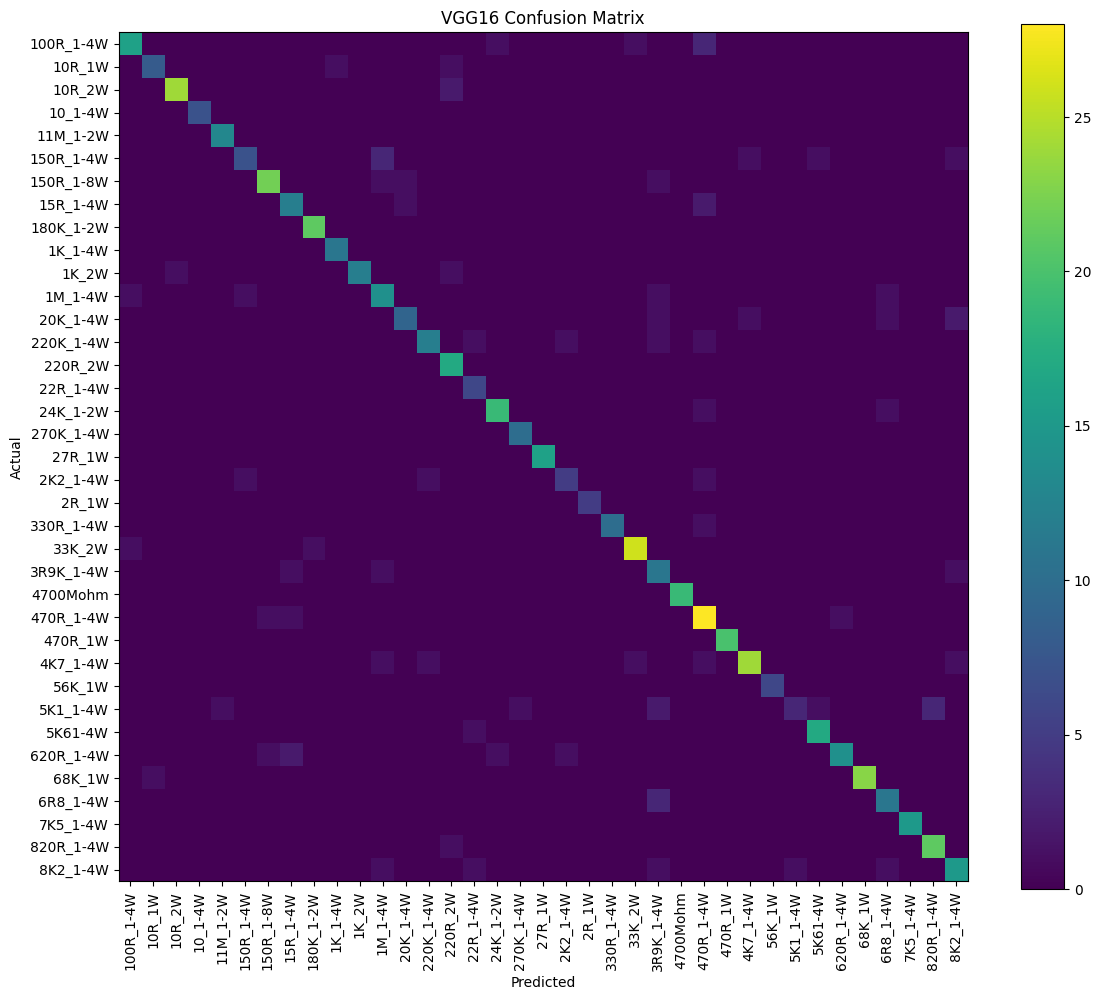

              precision    recall  f1-score   support

   100R_1-4W       0.89      0.76      0.82        21
      10R_1W       0.89      0.80      0.84        10
      10R_2W       0.96      0.92      0.94        26
     10_1-4W       1.00      1.00      1.00         7
    11M_1-2W       0.93      1.00      0.96        13
   150R_1-4W       0.78      0.54      0.64        13
   150R_1-8W       0.92      0.88      0.90        25
    15R_1-4W       0.75      0.80      0.77        15
   180K_1-2W       0.95      1.00      0.98        21
     1K_1-4W       0.92      1.00      0.96        11
       1K_2W       1.00      0.86      0.92        14
     1M_1-4W       0.67      0.78      0.72        18
    20K_1-4W       0.82      0.64      0.72        14
   220K_1-4W       0.86      0.75      0.80        16
     220R_2W       0.77      1.00      0.87        17
    22R_1-4W       0.67      1.00      0.80         6
    24K_1-2W       0.90      0.90      0.90        21
   270K_1-4W       0.91    

In [6]:
# 4. PLOTS — TRAINING vs VALIDATION
# ------------------------------------------------------------

plot_history(history_vgg, "VGG16 Transfer Learning")

vgg_test_loss, vgg_test_acc = vgg_model.evaluate(test_vgg)
print(f"VGG16 Test Accuracy: {vgg_test_acc:.4f}")

# ================= CONFUSION MATRIX =================

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_vgg:
    preds = vgg_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.imshow(cm)
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)

plt.colorbar()
plt.tight_layout()
plt.show()

# Optional report
print(classification_report(y_true, y_pred, target_names=class_names))


SMALL CNN SUMMARY


Model: "SmallCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466,821 (1.78 MB)

 Trainable params: 466,821 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 466821
Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 456ms/step - accuracy: 0.0412 - loss: 3.5893 - val_accuracy: 0.0729 - val_loss: 3.5509
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 414ms/step - accuracy: 0.0560 - loss: 3.4840 - val_accuracy: 0.0903 - val_loss: 3.3893
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 245ms/step - accuracy: 0.0819 - loss: 3.2873 - val_accuracy: 0.0920 - val_loss: 3.1351
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 247ms/step - accuracy: 0.0949 - loss: 3.1382 - val_accuracy: 0.1042 - val_loss: 2.9946
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.0984 - loss: 3.0539 - val_accuracy: 0.1493 - val_loss: 2.9013
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 414ms/step - accuracy: 0.1221 - loss: 2.9652 - val_accuracy: 0.1823 - val_loss: 2.8525
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 253ms/step - accuracy: 0.1461 - loss: 2.8839 - val_accuracy: 0.1701 - val_loss: 2.7476
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 414ms/step - accuracy: 0.1709 

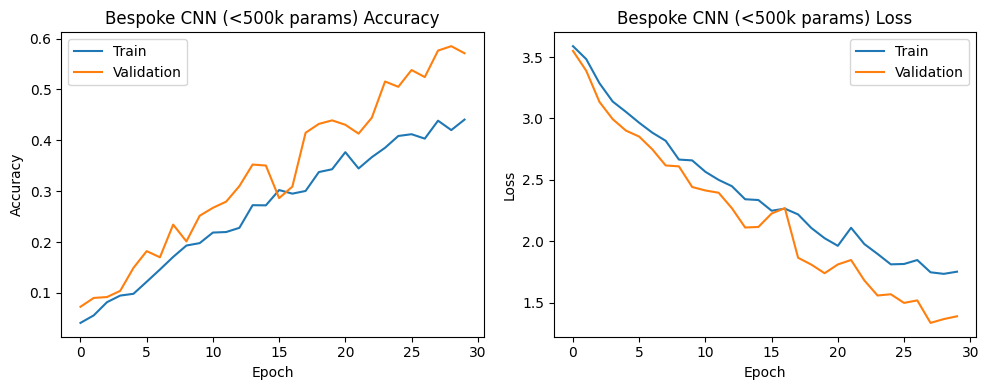

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5806 - loss: 1.3276
Custom CNN Test Accuracy: 0.5806


In [ ]:
# Bespoke
from tensorflow.keras import layers, Model

# Normalisation for custom CNN
train_cnn = train_ds.map(lambda x, y: (x/255.0, y))
val_cnn   = val_ds.map(lambda x, y: (x/255.0, y))
test_cnn  = test_ds.map(lambda x, y: (x/255.0, y))

def build_small_cnn(num_classes):
    inp = layers.Input(shape=(224,224,3))

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)   # 224 -> 112

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)   # 112 -> 56

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)   # 56 -> 28

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)   # 28 -> 14
    x = layers.MaxPooling2D()(x)   # 14 -> 7

    x = layers.Flatten()(x)        # 7 x 7 x 64 = 3,136

    x = layers.Dense(128, activation="relu")(x) # Reduced dense layer from 256 to 128, added an extra MaxPooling layer
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inp, out, name="SmallCNN")

small_cnn = build_small_cnn(NUM_CLASSES)

small_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nSMALL CNN SUMMARY")
small_cnn.summary()
print("Total parameters:", small_cnn.count_params())

history_cnn = small_cnn.fit(
    train_cnn,
    validation_data=val_cnn,
    epochs=30
)

plot_history(history_cnn, "Bespoke CNN (<500k params)")

cnn_test_loss, cnn_test_acc = small_cnn.evaluate(test_cnn)
print(f"Custom CNN Test Accuracy: {cnn_test_acc:.4f}")

In [ ]:
from tensorflow.keras.applications import VGG16

# Load original VGG16 (ImageNet)
vgg16 = VGG16(
    weights="imagenet",
    include_top=True  # includes the original classifier
)

# Print full model summary
vgg16.summary()

# Explicit parameter breakdown
total_params = vgg16.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in vgg16.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in vgg16.non_trainable_weights])

print("\nVGG16 PARAMETER SUMMARY")
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Non-trainable params  : {non_trainable_params:,}")

print("\nArchitecture Note:")
print("VGG16 consists of 13 convolutional layers and 3 fully connected layers.")
print("The majority of parameters (>90%) are located in the fully connected layers.")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)


VGG16 PARAMETER SUMMARY
Total parameters      : 138,357,544
Trainable parameters  : 138,357,544
Non-trainable params  : 0

Architecture Note:
VGG16 consists of 13 convolutional layers and 3 fully connected layers.
The majority of parameters (>90%) are located in the fully connected layers.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model

# ------------------------------------------------------------
# Load ORIGINAL VGG16 with full classifier
# ------------------------------------------------------------
vgg16_full = VGG16(
    weights="imagenet",
    include_top=True
)

# ------------------------------------------------------------
# Remove ONLY the ImageNet prediction layer (1000-class softmax)
# Keep fc1 (4096) and fc2 (4096)
# ------------------------------------------------------------
vgg16_base = Model(
    inputs=vgg16_full.input,
    outputs=vgg16_full.layers[-2].output  # fc2 layer (4096 units)
)

# Freeze all original VGG16 parameters (~134M)
vgg16_base.trainable = False

# ------------------------------------------------------------
# Add new task-specific prediction layer (37 classes)
# ------------------------------------------------------------
predictions = layers.Dense(
    37,
    activation="softmax",
    name="resistor_predictions"
)(vgg16_base.output)

# Final transfer learning model
vgg16_37class = Model(
    inputs=vgg16_base.input,
    outputs=predictions
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------
vgg16_37class.summary()

# ------------------------------------------------------------
# Parameter breakdown
# ------------------------------------------------------------
total_params = vgg16_37class.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in vgg16_37class.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in vgg16_37class.non_trainable_weights
)

print("\nVGG16 PARAMETER BREAKDOWN (TRANSFER LEARNING)")
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Non-trainable params  : {non_trainable_params:,}")

# Explicit mathematical confirmation
print("\nTrainable parameter calculation:")
print("(4096 × 37) + 37 =", (4096 * 37) + 37)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resistor_predictions (Dense)    │ (None, 37)             │       151,589 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,412,133 (512.74 MB)

 Trainable params: 151,589 (592.14 KB)

 Non-trainable params: 134,260,544 (512.16 MB)


VGG16 PARAMETER BREAKDOWN (TRANSFER LEARNING)
Total parameters      : 134,412,133
Trainable parameters  : 151,589
Non-trainable params  : 134,260,544

Trainable parameter calculation:
(4096 × 37) + 37 = 151589


In [ ]:
# 6. FINAL COMPARISON (FOR POSTER)
# ------------------------------------------------------------
print("\n================ FINAL RESULTS ================")
print(f"VGG16 Transfer Learning Accuracy: {vgg_test_acc:.4f}")
print(f"Bespoke CNN Accuracy:            {cnn_test_acc:.4f}")
print("================================================")


================ FINAL RESULTS ================
VGG16 Transfer Learning Accuracy: 0.8799
Bespoke CNN Accuracy:            0.2664
